Load a dataset (Titanic Dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats

Creating a dataframe for both train and test.

In [49]:
df = pd.read_csv('/home/ice/WinDocuments/ml_datasets/titanic_dataset/train.csv')
df_features = df.drop('Survived', axis=1)
df_labels = df['Survived']

Checking the dataFrame for Nan/Null values.

In [50]:
df_train_features_nulls = df_features.isnull().sum()
print(df_train_features_nulls)

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


As we can see Age, Cabin and Embarked have 177, 687, 2 Null values respectively. We can choose to employ several strategies for all three.

Age feature has large number of Nan values but it might be crucial to predicting if the passenger survives or not depending on their abilities (Younger people are more athletic generally). So, We can use Simple imputer to impute/replace Nan values by mean,median,or mode/most frequent.

In [16]:
df_features['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [20]:
df_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
df_mean.fit(df_features[['Age']]) 
df_features['Age'] = df_mean.transform(df_features[['Age']]).ravel()

Similarly we can impute the Embarked feature as well, but this time we use strategy as most frequent as the data is categorical.

In [21]:
df_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df_mode.fit(df_features[['Embarked']])
df_features['Embarked'] = df_mode.transform(df_features[['Embarked']]).ravel()

As we have 891 total entries for the test data and cabin have 687 Nan values, we should drop this feature as this doesn't provide any additional relation to the label.

In [22]:
df_features.drop('Cabin', axis=1, inplace=True)
df_features.drop('PassengerId', axis=1, inplace=True)
df_features.drop('Name', axis=1, inplace=True)
df_features.drop('Ticket', axis=1, inplace=True)

We can check and confirm that the Nan values have been imputed or dropped, like in the case of cabin.

In [23]:
df_features.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Encoding of categorical data.

In [24]:
encode_sex = ['male','female']
encode_embarked = set(df_features['Embarked'])
Sex = df_features['Sex']
Sex = Sex.replace(encode_sex,[0,1])
Embarked = df_features['Embarked']
Embarked = Embarked.replace(encode_embarked, [0,1,2])
df_features['Sex'] = Sex
df_features['Embarked'] = Embarked
df_features.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,2
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


2.Creating histograms, sctter plots, box plots, and heatmaps to visualize different features.

<AxesSubplot: xlabel='Age', ylabel='Count'>

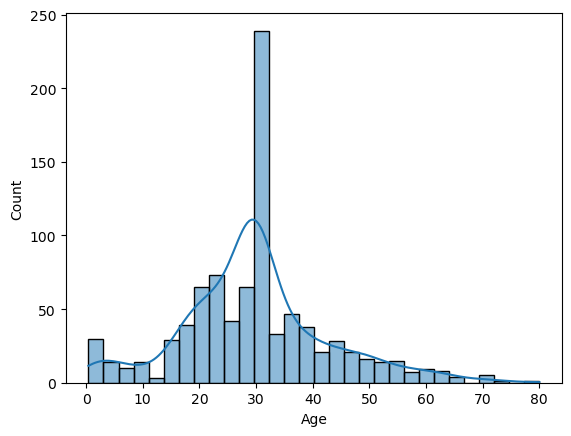

In [25]:
sns.histplot(df_features['Age'],kde='True')

<AxesSubplot: xlabel='Fare', ylabel='Count'>

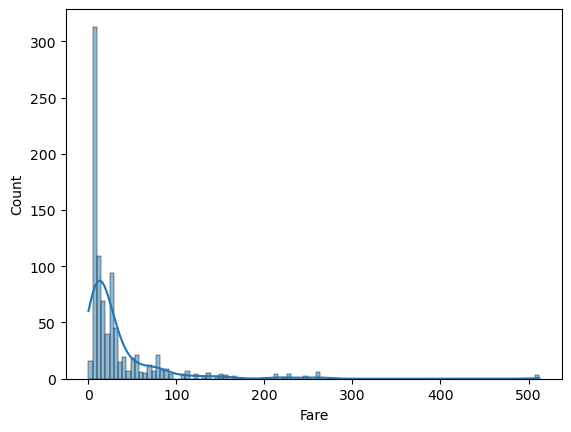

In [27]:
sns.histplot(df_features['Fare'],kde='True')

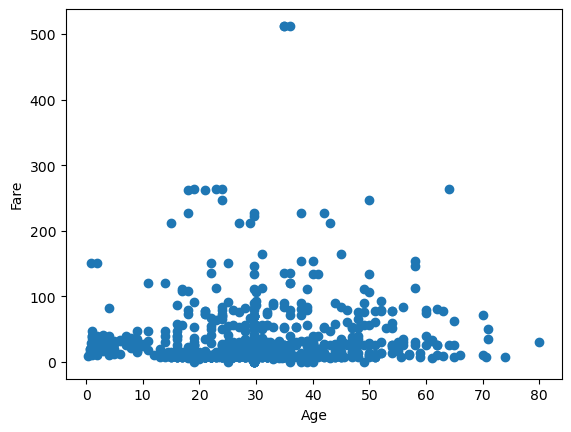

In [28]:
plt.scatter(df_features['Age'],df_features['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

<AxesSubplot: >

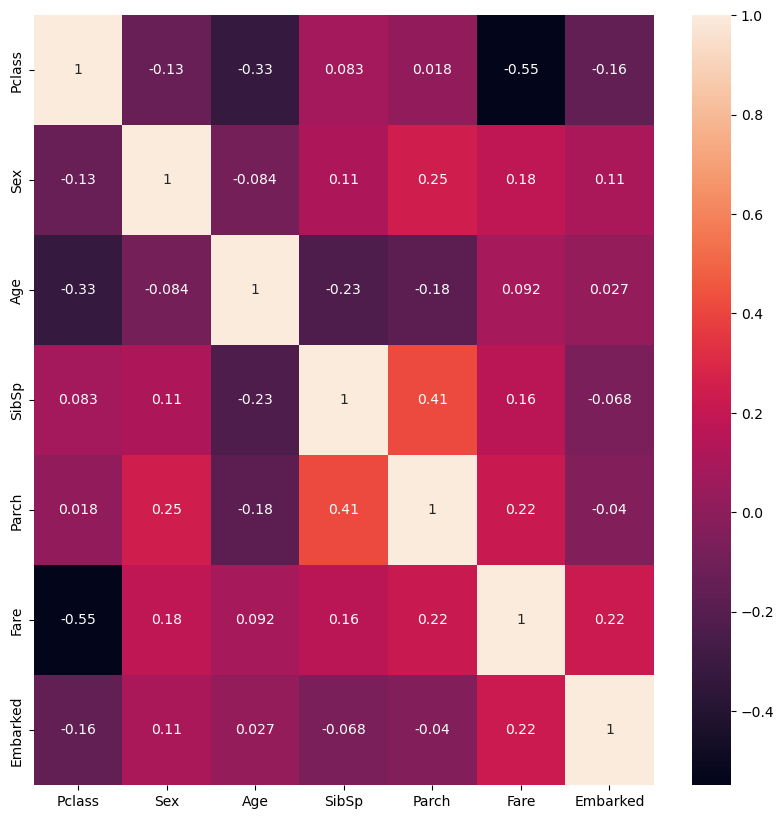

In [30]:
plt.figure(figsize=(10,10))
sns.heatmap(df_features.corr(),annot=True)

<AxesSubplot: >

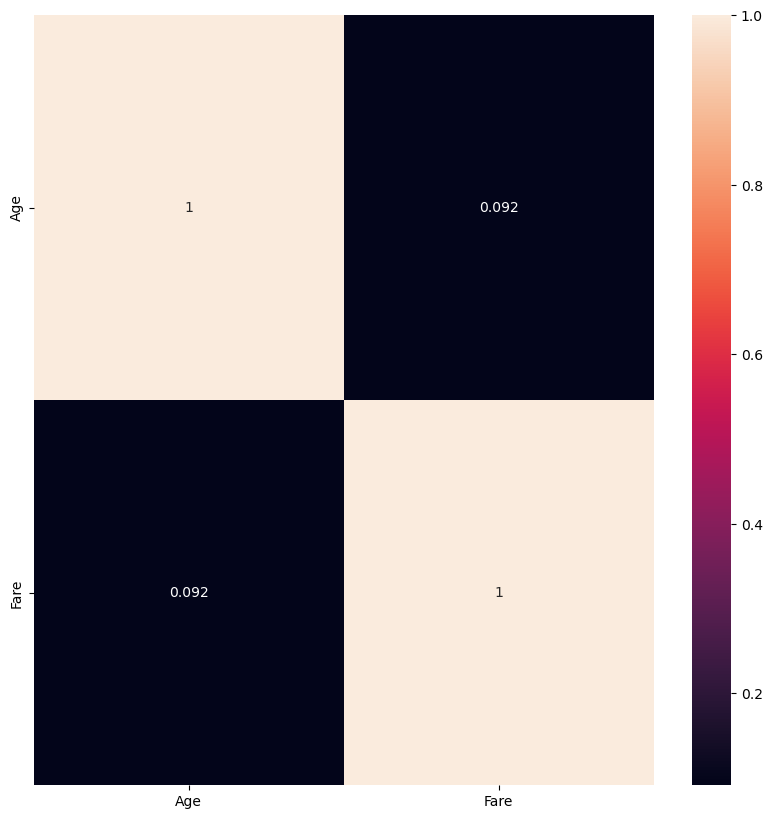

In [31]:
plt.figure(figsize=(10,10))
sns.heatmap(df_features[['Age','Fare']].corr(),annot=True)

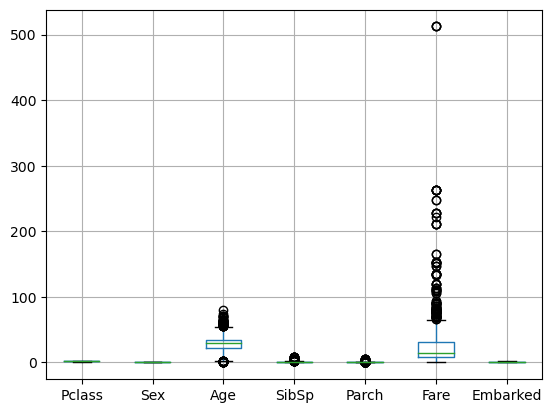

In [33]:
boxplot = df_features.boxplot(column=list(df_features.columns))

3.Interpret the visualizations to understand data distributions and relationships.

The Age distribution appears to be slightly right-skewed, with a majority of passengers falling between the ages of 20 and 40.
The Fare distribution is heavily right-skewed, with most fares clustered at the lower end and a long tail of more expensive fares.

The scatter plot of Age vs. Fare doesn't reveal a strong linear relationship,
but it suggests that there might be some higher fares associated with older passengers.

The heatmap confirms a weak positive correlation between Age and Fare.

The box plots show the presence of outliers in both Age and Fare,
particularly in the Fare distribution where there are several high-priced outliers.

In [36]:
X_train,X_test,Y_train,Y_test = train_test_split(df_features,df_labels,test_size=0.3)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
433,3,0,17.000000,0,0,7.1250,0
116,3,0,70.500000,0,0,7.7500,1
722,2,0,34.000000,0,0,13.0000,0
605,3,0,36.000000,1,0,15.5500,0
452,1,0,30.000000,0,0,27.7500,2
...,...,...,...,...,...,...,...
520,1,1,30.000000,0,0,93.5000,0
64,1,0,29.699118,0,0,27.7208,2
440,2,1,45.000000,1,1,26.2500,0
574,3,0,16.000000,0,0,8.0500,0


# Scaling the data.

In [48]:
scaler = StandardScaler()
scaling_train = pd.DataFrame(X_train[['Age','Fare']])
X_scaled = scaler.fit_transform(scaling_train).ravel()
X_train['Age'] = X_scaled[0:668]
X_train['Fare'] = X_scaled[668:]
X_train

ValueError: Length of values (668) does not match length of index (623)

D

In [80]:
model = LogisticRegression()

#

In [140]:
model.fit(np.array(X_train),Y_train.ravel())

LogisticRegression()

In [142]:
Y_pred = model.predict(np.array(X_test))
Y_test = Y_test.ravel()

In [144]:
def accu_score(Y_pred,Y_test):
    avg = []
    for i in range(0,len(Y_test)):
        avg.append(Y_pred[i]^Y_test[i])
    return sum(avg)/len(avg)
print(1-accu_score(Y_pred,Y_test))

0.6502242152466368


In [151]:
model.predict([[2,0,-0.445448,0,0,-0.607525,0]])

array([0])